In [1]:
## Imports

In [2]:
import scanpy as sc
import numpy as np
import scipy as sp
import os, sys
from pathlib import Path
_p = Path(".").resolve()
while not (_p / "src" / "config.py").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))
from src.config import ANALYSIS_DIR, DATA_DIR


In [4]:
d4_lapa = sc.read_h5ad(DATA_DIR / "data-objects/raw/egfDuod_D4_Lapa_DZ.h5ad")

In [5]:
d4_lapa

AnnData object with n_obs × n_vars = 34969 × 26742
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident'
    uns: 'X_name'
    layers: 'counts'

In [6]:
d4_lapa.var["mt"] = d4_lapa.var_names.str.startswith("MT-")

In [7]:
d4_lapa

AnnData object with n_obs × n_vars = 34969 × 26742
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident'
    var: 'mt'
    uns: 'X_name'
    layers: 'counts'

In [8]:
d4_lapa.var["ribo"] = d4_lapa.var_names.str.startswith(("RPS", "RPL"))


In [9]:
sc.pp.calculate_qc_metrics(d4_lapa, qc_vars=["mt", "ribo"], inplace=True, log1p=True)

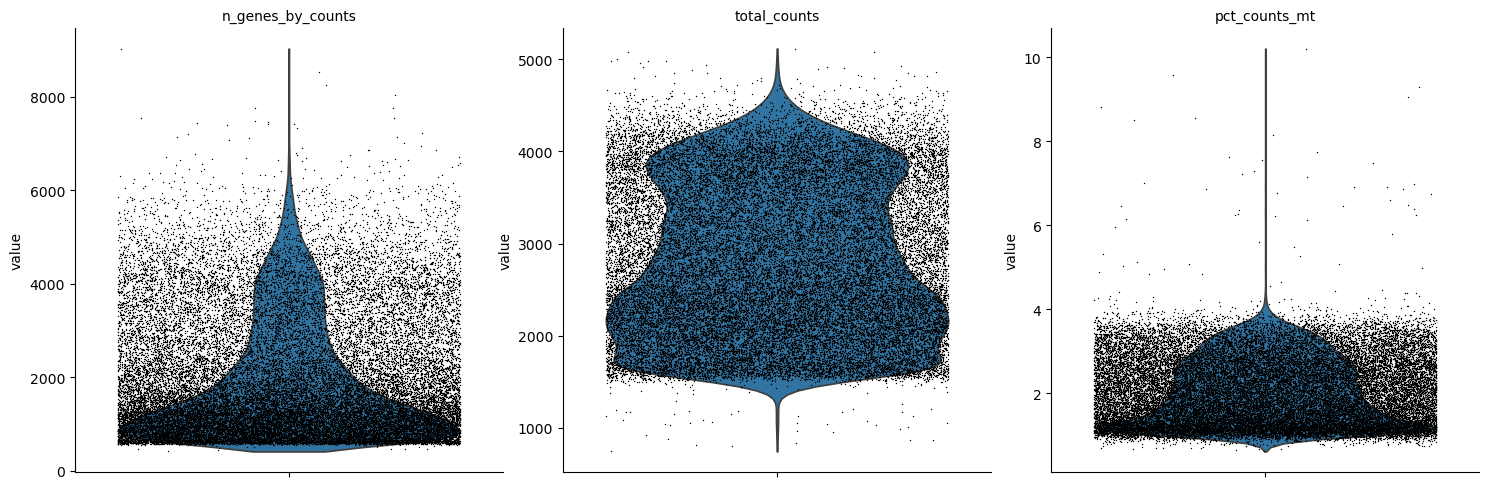

In [10]:
sc.pl.violin(
    d4_lapa,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

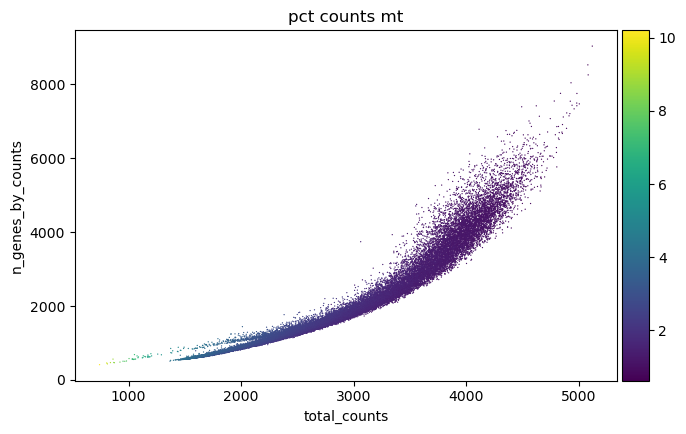

In [11]:
sc.pl.scatter(d4_lapa, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [12]:
d4_lapa.obs[['n_genes_by_counts','total_counts','pct_counts_mt']].describe()


,n_genes_by_counts,total_counts,pct_counts_mt
count,34969.000000,34969.000000,34969.000000
mean,1980.397667,2803.573507,2.063153
std,1292.460111,821.833030,0.799612
min,409.000000,742.446604,0.622306
25%,960.000000,2100.004971,1.347162
50%,1514.000000,2699.597042,1.955676
75%,2761.000000,3520.867928,2.676817
max,9034.000000,5117.382495,10.204584


In [13]:
sc.pp.scrublet(d4_lapa)

In [14]:
d4_lapa

AnnData object with n_obs × n_vars = 34969 × 26742
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'X_name', 'scrublet'
    layers: 'counts'

In [15]:
d4_lapa.obs[['doublet_score']].describe()


,doublet_score
count,34969.000000
mean,0.114460
std,0.088488
min,0.002984
25%,0.051275
50%,0.093004
75%,0.149425
max,0.787709


In [16]:
d4_lapa.obs[['predicted_doublet']].describe()


,predicted_doublet
count,34969
unique,2
top,False
freq,34968


In [17]:
## we need to set the parameter for the threshold of 'predicted doublet', we're failing to do so manually

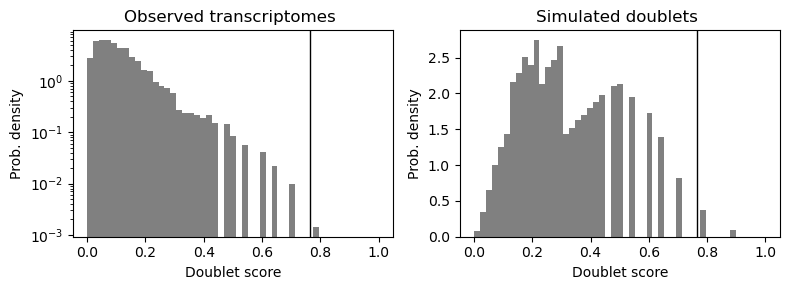

In [18]:
sc.pl.scrublet_score_distribution(d4_lapa)

In [19]:
intermediate_directory = str(ANALYSIS_DIR / "data-objects/qc")
sc.write(f'{intermediate_directory}/doublet_egfDuod_D4_Lapa_DZ.h5ad', d4_lapa)